# LightGBM Baseline - PS-S06E08: Predicting Smartphone Addiction

This notebook implements a LightGBM baseline for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**. The target is `addicted_label` (0 = Not Addicted, 1 = Addicted), and the evaluation metric is **ROC AUC**.

We employ Stratified 5-Fold cross-validation, multi-seed training, hyperparameter tuning with an SQLite-backed Optuna database, and out-of-fold/test predictions logging for ensembling.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='LightGBM',
    use_gpu=False,  # Run on CPU to avoid GPU split assertions
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags'
]

print('Performing feature engineering...')
factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = training_df[TARGET].copy()

X = factory.fit_transform(training_df)
X_test = factory.transform(test_df)

print(f'Train features shape: {X.shape}')
print(f'Test features shape: {X_test.shape}')

Performing feature engineering...
  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
Applying FeatureFactory with strategies: encoding, screen_time_ratios, sleep_stress, risk_score, missing_flags
  -> Imputing missing values using learned medians and modes...
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding screen time ratio features...
  -> Adding sleep_stress interaction features...
  -> Adding lifestyle risk score features...
Train features shape: (691369, 42)
Test features shape: (296302, 42)


## 4. Recursive Feature Elimination (RFE)

Uses RFECV to select a robust subset of features when active. Otherwise, loads previously saved feature names.

In [5]:
# Convert categories to integer codes for RFECV compatibility
X_rfe = X.copy()
cat_cols = X_rfe.select_dtypes(include=['category']).columns.tolist()
for c in cat_cols:
    X_rfe[c] = X_rfe[c].cat.codes

if setup.perform_rfe():
    from sklearn.feature_selection import RFECV
    from lightgbm import LGBMClassifier
    
    print("Running RFECV on a 50k row sample for speed...")
    estimator = LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=seed,
        verbosity=-1
    )
    
    sample_idx = X_rfe.sample(n=min(50000, len(X_rfe)), random_state=seed).index
    selector = RFECV(estimator, step=1, cv=3, scoring='roc_auc', n_jobs=-1)
    selector.fit(X_rfe.loc[sample_idx], y.loc[sample_idx])
    optimal_cols = X.columns[selector.support_]
    
    setup.save_rfe('selected_features_lgb.json', optimal_cols)
    setup.upload_artifact('selected_features_lgb.json')
else:
    optimal_cols = setup.load_rfe('selected_features_lgb.json', X)

X = X[optimal_cols]
X_test = X_test[optimal_cols]

print(f"Selected features count: {len(X.columns)}")
print("Features list:", list(X.columns))

RFE file 'selected_features_lgb.json' not found — using all 42 columns.
Selected features count: 42
Features list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'is_missing_age', 'is_missing_daily_screen_time_hours', 'is_missing_social_media_hours', 'is_missing_gaming_hours', 'is_missing_work_study_hours', 'is_missing_sleep_hours', 'is_missing_notifications_per_day', 'is_missing_app_opens_per_day', 'is_missing_weekend_screen_time', 'is_missing_gender', 'is_missing_stress_level', 'is_missing_academic_work_impact', 'social_media_fraction', 'gaming_fraction', 'total_social_gaming_hours', 'non_social_gaming_hours', 'weekend_to_weekday_ratio', 'app_opens_per_hour', 'notifications_per_hour', 'screen_time_per_age', 'app_opens_per_age', 'notifications_per_age', 'notifications_per_app_open', 'app_opens_to_notificatio

## 5. SQLite-Backed Optuna Optimization

Performs hyperparameter search over a 5-fold CV split, caching trials dynamically in an SQLite database.

In [6]:
# Setup Stratified CV fold cache to prevent redundant feature copies
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
for tr_idx, val_idx in skf_cv.split(X, y):
    fold_cache.append((tr_idx, val_idx))

def objective(trial):
    params = {
        'n_estimators': 3000,
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),  # Reduced max leaves to 255 for CPU speed & stability
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': seed,
        'n_jobs': -1,  # Multi-threaded CPU execution
        'verbosity': -1
    }
    
    oof_preds = np.full(len(y), -1.0, dtype=float)
    
    for fold, (tr_idx, val_idx) in enumerate(fold_cache):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        
        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
        fold_score = roc_auc_score(y_val, preds)
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    filled_mask = oof_preds >= 0
    return roc_auc_score(y[filled_mask], oof_preds[filled_mask])

In [7]:
optuna_filename = 'optuna_params_lgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print("Starting LightGBM SQLite Optuna Optimization...")
    
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1
    )
    
    # Suffix with _v2 to segregate clean CPU search from failed GPU trials
    study = optuna.create_study(
        storage='sqlite:///lgbm_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='lgbm_predict_smartphone_addiction_optuna_v2',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    # Seed with current best parameters if study is empty
    if len(study.trials) == 0 and len(best_params) > 0:
        study.enqueue_trial(best_params)
        
    study.optimize(
        objective,
        n_trials=30,
        show_progress_bar=True,
        timeout=7200
    )
    best_params = study.best_params
    print("Best params found:", best_params)
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print("Using loaded parameters:", best_params)

Loaded 9 parameters from optuna_params_lgb.json
Starting LightGBM SQLite Optuna Optimization...


[I 2026-08-03 10:59:45,626] Using an existing study with name 'lgbm_predict_smartphone_addiction_optuna_v2' instead of creating a new one.
[I 2026-08-03 11:04:59,247] Trial 11 finished with value: 0.9630217184871556 and parameters: {'learning_rate': 0.050339676949738434, 'num_leaves': 95, 'max_depth': 8, 'min_child_samples': 61, 'subsample': 0.8001422417861698, 'subsample_freq': 2, 'colsample_bytree': 0.8728268230022258, 'reg_alpha': 0.10139379822867754, 'reg_lambda': 2.1316066555723932e-05}. Best is trial 1 with value: 0.9634968911512078.
[I 2026-08-03 11:13:49,695] Trial 12 finished with value: 0.9635062298881758 and parameters: {'learning_rate': 0.06518213342095727, 'num_leaves': 100, 'max_depth': 4, 'min_child_samples': 37, 'subsample': 0.9128306854068973, 'subsample_freq': 2, 'colsample_bytree': 0.7265851339316457, 'reg_alpha': 2.651789551898209, 'reg_lambda': 0.0003354654278894863}. Best is trial 12 with value: 0.9635062298881758.
[I 2026-08-03 11:23:02,234] Trial 13 finished wit

Best params found: {'learning_rate': 0.07341733634273985, 'num_leaves': 50, 'max_depth': 4, 'min_child_samples': 35, 'subsample': 0.9789618403284047, 'subsample_freq': 1, 'colsample_bytree': 0.7773640540164757, 'reg_alpha': 8.398547059780682, 'reg_lambda': 0.0027919420188418586}
Saved 9 parameters to optuna_params_lgb.json

Uploading optuna_params_lgb.json to Kaggle dataset...
Downloaded metadata to kaggle_upload_artifacts/dataset-metadata.json
Dataset URL: https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
License(s): CC0-1.0

  Including local file: optuna_params_lgb.json


100%|██████████| 716/716 [00:00<00:00, 1.39MB/s]
  0%|          | 0.00/280 [00:00<?, ?B/s]

Starting upload for file optuna_params_lgb.json


100%|██████████| 280/280 [00:00<00:00, 543B/s]
  0%|          | 0.00/291 [00:00<?, ?B/s]

Upload successful: optuna_params_lgb.json (280B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 291/291 [00:00<00:00, 630B/s]


Upload successful: optuna_params_xgb.json (291B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


## 6. Model Training & Multi-Seed Blending

Trains the model across multiple seeds and fold splits to construct out-of-fold (OOF) predictions and test set probabilities.

In [8]:
seeds = setup.seed()

# Track multi-class style probabilities: column 0 = prob(0), column 1 = prob(1)
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.zeros(len(X), dtype=bool)

models = []
eval_results = []

for s_idx, current_seed in enumerate(seeds):
    print(f"\n================ SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed} ================")
    
    lgb_params = {
        **best_params,
        'n_estimators': 4000,
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'random_state': current_seed,
        'n_jobs': -1,  # Multi-threaded CPU execution
        'verbosity': -1
    }
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    oof_probs_seed = np.zeros((len(X), 2))
    test_probs_seed = np.zeros((len(X_test), 2))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            eval_metric='auc',
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=200)
            ]
        )
        
        # Predict probabilities
        val_probs = model.predict_proba(X_val)
        oof_probs_seed[val_idx] = val_probs
        filled_mask[val_idx] = True
        
        test_probs_seed += model.predict_proba(X_test) / 5.0
        
        fold_score = roc_auc_score(y_val, val_probs[:, 1])
        n_trees = model.booster_.num_trees()
        print(f"  Fold {fold+1} ROC AUC: {fold_score:.6f} (trees={n_trees})")
        
        models.append(model)
        eval_results.append(model.evals_result_)
        
    seed_score = roc_auc_score(y, oof_probs_seed[:, 1])
    print(f"--- Seed {current_seed} CV ROC AUC: {seed_score:.6f} ---")
    
    oof_probs += oof_probs_seed / len(seeds)
    test_probs += test_probs_seed / len(seeds)
    
overall_score = roc_auc_score(y[filled_mask], oof_probs[filled_mask, 1])
print("\n" + "="*60)
print(f"Seed-Averaged CV ROC AUC: {overall_score:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================
[200]	training's auc: 0.946163	valid_1's auc: 0.945067
[400]	training's auc: 0.955414	valid_1's auc: 0.953827
[600]	training's auc: 0.959302	valid_1's auc: 0.957289
[800]	training's auc: 0.961634	valid_1's auc: 0.959218
[1000]	training's auc: 0.963175	valid_1's auc: 0.960387
[1200]	training's auc: 0.964308	valid_1's auc: 0.961136
[1400]	training's auc: 0.965215	valid_1's auc: 0.96166
[1600]	training's auc: 0.965999	valid_1's auc: 0.962078
[1800]	training's auc: 0.966656	valid_1's auc: 0.962353
[2000]	training's auc: 0.967255	valid_1's auc: 0.962568
[2200]	training's auc: 0.967783	valid_1's auc: 0.962725
[2400]	training's auc: 0.968289	valid_1's auc: 0.962864
[2600]	training's auc: 0.96876	valid_1's auc: 0.962985
[2800]	training's auc: 0.969209	valid_1's auc: 0.963082
[3000]	training's auc: 0.969629	valid_1's auc: 0.963143
[3200]	training's auc: 0.970036	valid_1's auc: 0.963229
[3400]	training's auc: 0.97042	valid_1's auc: 0.96

## 7. Performance Visualization

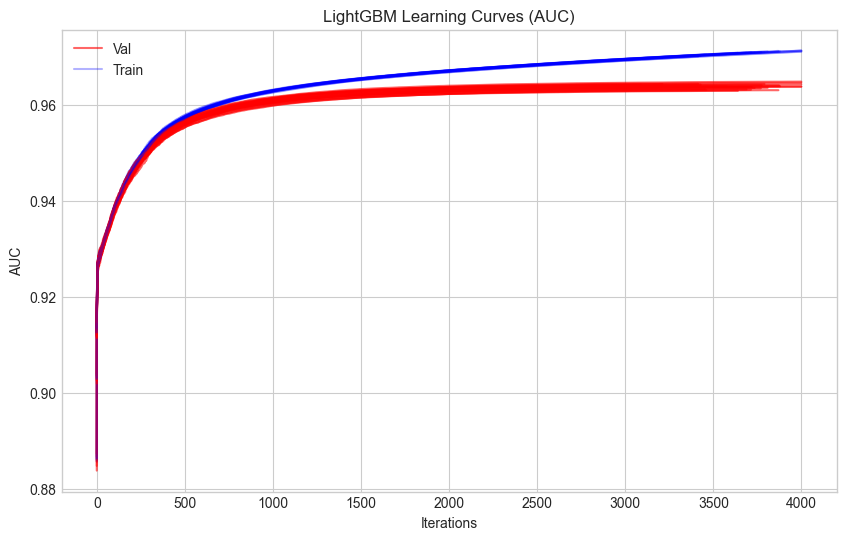

In [9]:
mviz = ModelVisualizer(model_name='LightGBM')

# Map learning metrics to ModelVisualizer expectations
adjusted_evals = []
for res in eval_results:
    adjusted_evals.append({
        'validation_0': res['valid_1'],
        'validation_1': res['training']
    })

mviz.plot_learning_curves(adjusted_evals, metric='auc')

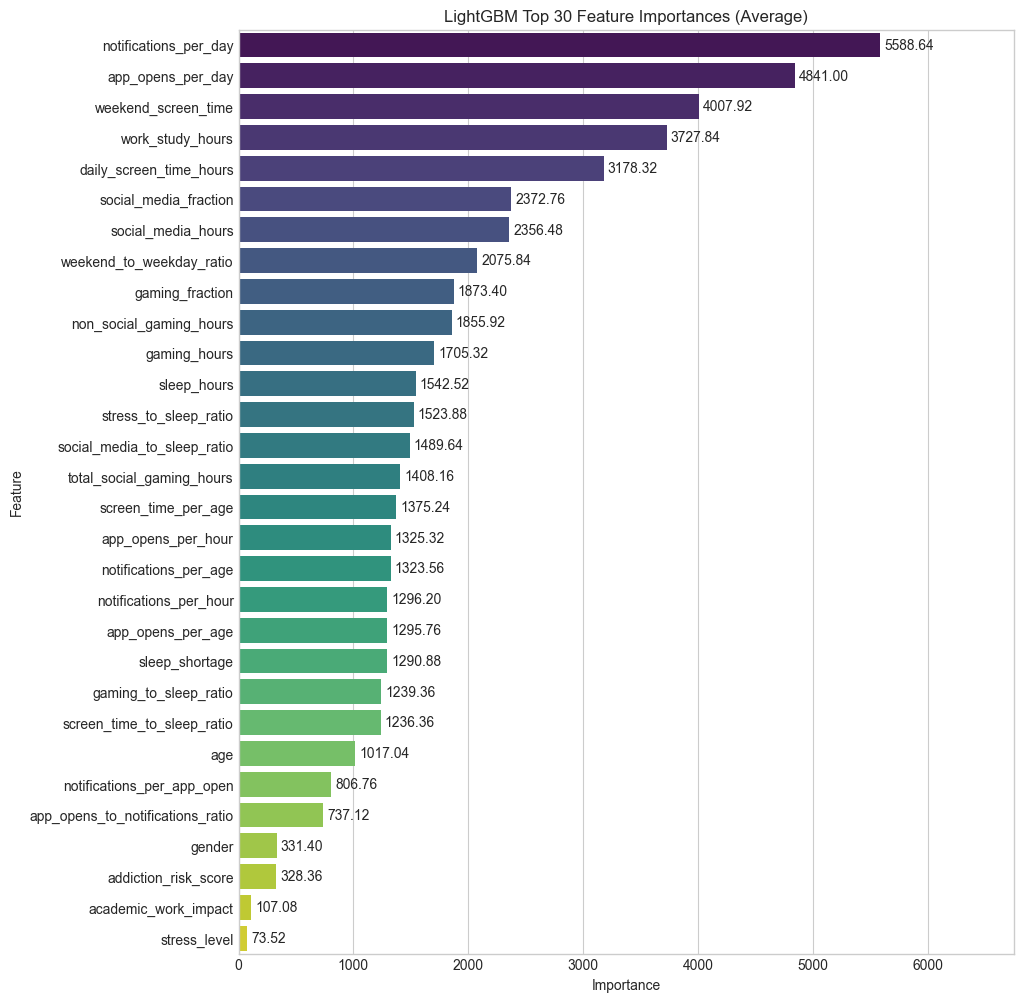

In [10]:
mviz.plot_feature_importance(models, show_values=True)

<Figure size 800x600 with 0 Axes>

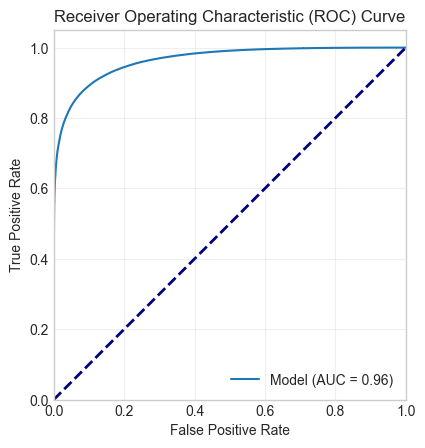

In [11]:
mviz.plot_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask, 1])

Confusion matrix, without normalization


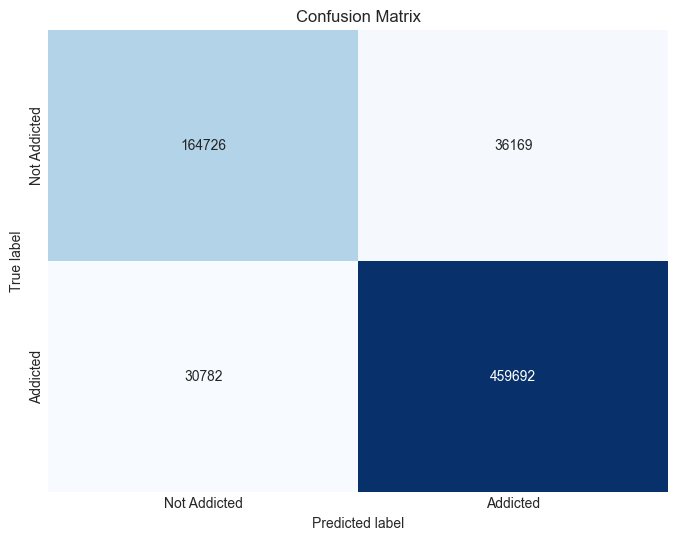

In [12]:
y_pred_class = (oof_probs[:, 1] > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['Not Addicted', 'Addicted']
)

## 8. Export Submission & Predictions

In [13]:
submission_df = setup.read_dataset('submission')
submission_df['addicted_label'] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

Saved submission.csv successfully!


In [14]:
setup.save_probabilities('lgb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
